In [2]:
import cv2
img = cv2.imread('./images/input.jpg')
cv2.imshow('Input image', img)
cv2.waitKey()


error: OpenCV(4.12.0) C:\miniconda3\conda-bld\opencv-suite_1764690164812\work\modules\highgui\src\window.cpp:973: error: (-215:Assertion failed) size.width>0 && size.height>0 in function 'cv::imshow'


In [ ]:
import cv2
gray_img = cv2.imread('images/input.jpg', cv2.IMREAD_GRAYSCALE)
cv2.imshow('Grayscale', gray_img)
cv2.waitKey()


In [ ]:
cv2.imwrite('images/output.jpg', gray_img)

In [ ]:
import cv2
img = cv2.imread('./images/input.jpg')
gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
cv2.imshow('Grayscale image', gray_img)
cv2.waitKey()


## 0. Load the Image (`fabio_gray_512`)

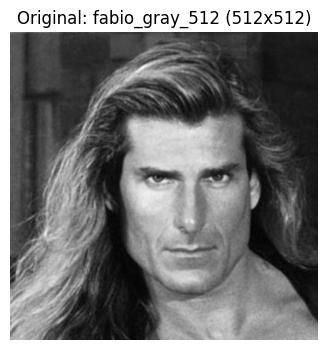

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img_path = 'images/fabio_gray_512.tif'
img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
h, w = img.shape
print(f"Loaded image: {img_path}, dimensions: {w}x{h}")

plt.figure(figsize=(4, 4))
plt.imshow(img, cmap='gray')
plt.title(f"Original: fabio_gray_512 ({w}x{h})")
plt.axis('off')
plt.show()

### Task 1.1: Increase the Size of the Image (Scaling / Resizing)

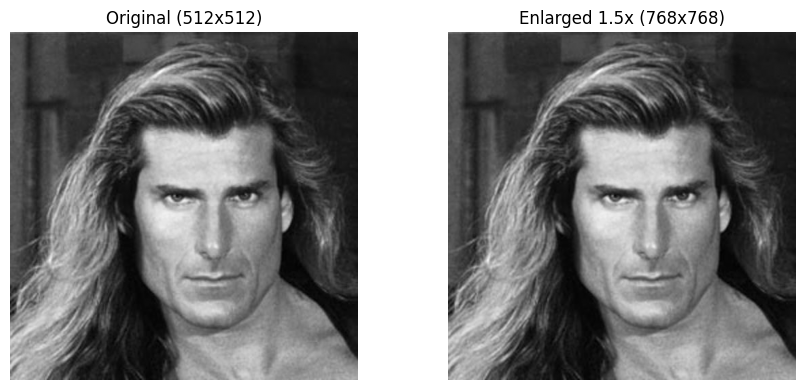

In [ ]:
# Increase the size by 1.5x (from 512x512 to 768x768)
scale_factor = 1.5
new_w, new_h = int(w * scale_factor), int(h * scale_factor)
img_enlarged = cv2.resize(img, (new_w, new_h), interpolation=cv2.INTER_CUBIC)

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
axes[0].imshow(img, cmap='gray')
axes[0].set_title(f"Original ({w}x{h})")
axes[0].axis('off')

axes[1].imshow(img_enlarged, cmap='gray')
axes[1].set_title(f"Enlarged 1.5x ({new_w}x{new_h})")
axes[1].axis('off')

plt.tight_layout()
plt.show()

### Task 1.2: Rotate the Image by 120 Degrees

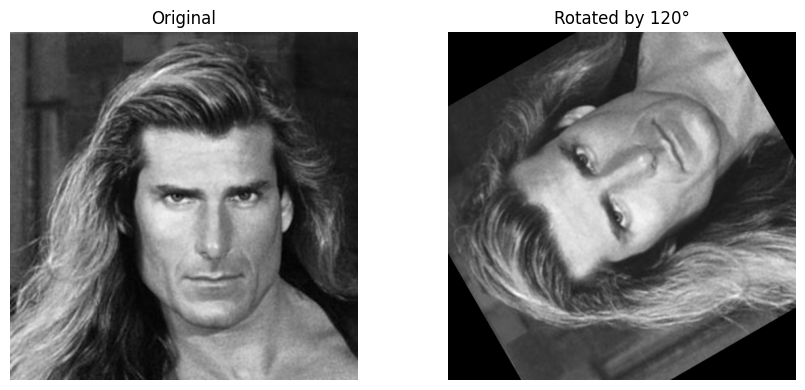

In [ ]:
# Rotate around center by 120 degrees
center = (w // 2, h // 2)
rot_mat = cv2.getRotationMatrix2D(center, angle=120, scale=1.0)
img_rotated = cv2.warpAffine(img, rot_mat, (w, h))

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
axes[0].imshow(img, cmap='gray')
axes[0].set_title("Original")
axes[0].axis('off')

axes[1].imshow(img_rotated, cmap='gray')
axes[1].set_title("Rotated by 120°")
axes[1].axis('off')

plt.tight_layout()
plt.show()

### Task 1.3: Perform Shear Operations Over the Image

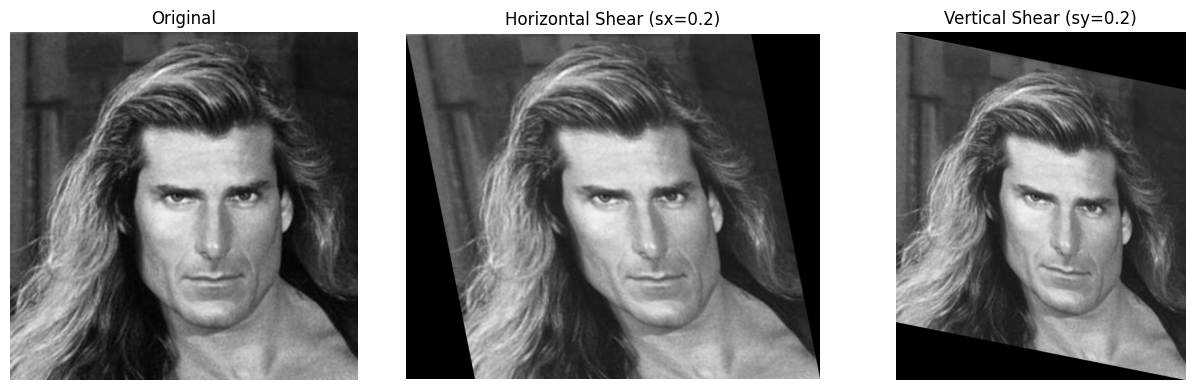

In [ ]:
# Horizontal shear: x' = x + sx * y, y' = y
shear_x = 0.2
M_shear_x = np.float32([
    [1, shear_x, 0],
    [0, 1,       0]
])
sheared_w = int(w + shear_x * h)
img_sheared_x = cv2.warpAffine(img, M_shear_x, (sheared_w, h))

# Vertical shear: x' = x, y' = y + sy * x
shear_y = 0.2
M_shear_y = np.float32([
    [1,       0, 0],
    [shear_y, 1, 0]
])
sheared_h = int(h + shear_y * w)
img_sheared_y = cv2.warpAffine(img, M_shear_y, (w, sheared_h))

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
axes[0].imshow(img, cmap='gray')
axes[0].set_title("Original")
axes[0].axis('off')

axes[1].imshow(img_sheared_x, cmap='gray')
axes[1].set_title(f"Horizontal Shear (sx={shear_x})")
axes[1].axis('off')

axes[2].imshow(img_sheared_y, cmap='gray')
axes[2].set_title(f"Vertical Shear (sy={shear_y})")
axes[2].axis('off')

plt.tight_layout()
plt.show()

### Task 2.1: Create a Negative Image

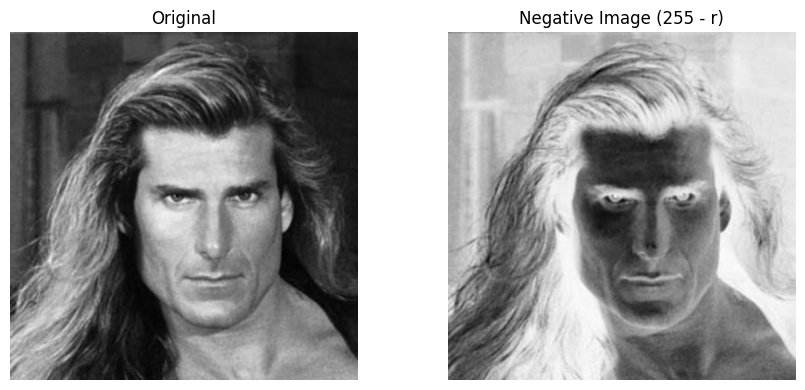

In [ ]:
# Negative Transformation: s = (L - 1) - r = 255 - r
img_negative = 255 - img

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
axes[0].imshow(img, cmap='gray')
axes[0].set_title("Original")
axes[0].axis('off')

axes[1].imshow(img_negative, cmap='gray')
axes[1].set_title("Negative Image (255 - r)")
axes[1].axis('off')

plt.tight_layout()
plt.show()

### Task 2.2: Log Transformation (with appropriate constant c)

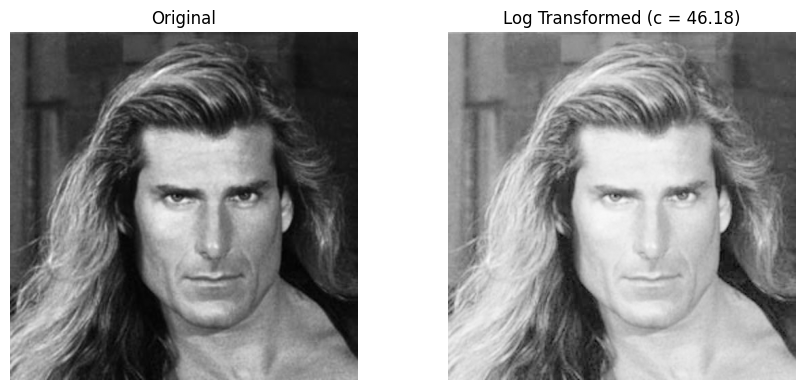

In [ ]:
# Log Transformation: s = c * log(1 + r)
# Constant c scales maximum output to 255: c = 255 / log(1 + r_max)
r_max = np.max(img)
c = 255.0 / np.log(1.0 + r_max)
img_log = np.array(c * np.log(1.0 + img.astype(np.float64)), dtype=np.uint8)

print(f"Max pixel value (r_max): {r_max}")
print(f"Calculated scaling constant c: {c:.2f}")

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
axes[0].imshow(img, cmap='gray')
axes[0].set_title("Original")
axes[0].axis('off')

axes[1].imshow(img_log, cmap='gray')
axes[1].set_title(f"Log Transformed (c = {c:.2f})")
axes[1].axis('off')

plt.tight_layout()
plt.show()

### Task 2.3: Power-law (Gamma) Transformation (increasing contrast)

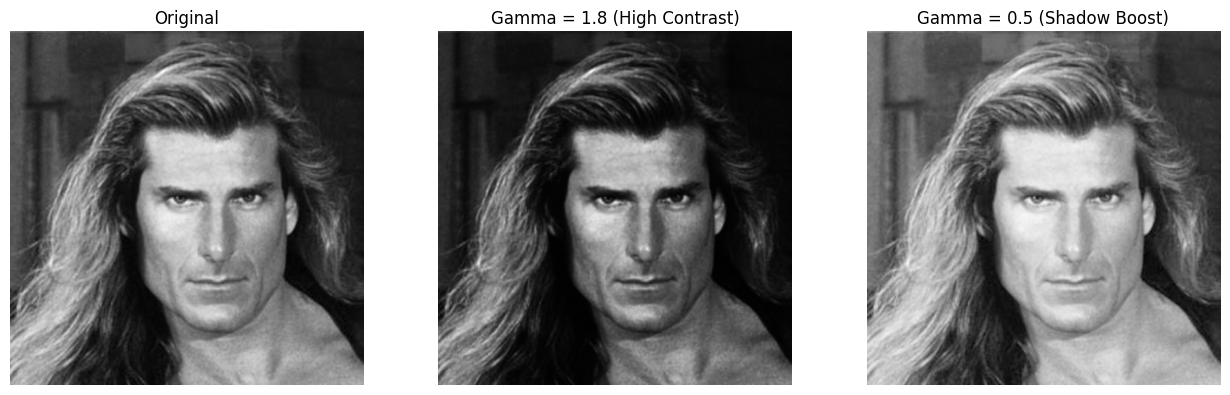

In [ ]:
# Power-law (Gamma) Transformation: s = 255 * (r / 255) ** gamma
# A gamma > 1 (e.g. gamma = 1.8) increases the contrast by expanding bright/mid values and darkening shadows
gamma_contrast = 1.8
img_gamma = np.array(255.0 * ((img / 255.0) ** gamma_contrast), dtype=np.uint8)

# For comparison, gamma < 1 (e.g. gamma = 0.5) brightens dark shadows
gamma_bright = 0.5
img_gamma_bright = np.array(255.0 * ((img / 255.0) ** gamma_bright), dtype=np.uint8)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
axes[0].imshow(img, cmap='gray')
axes[0].set_title("Original")
axes[0].axis('off')

axes[1].imshow(img_gamma, cmap='gray')
axes[1].set_title(f"Gamma = {gamma_contrast} (High Contrast)")
axes[1].axis('off')

axes[2].imshow(img_gamma_bright, cmap='gray')
axes[2].set_title(f"Gamma = {gamma_bright} (Shadow Boost)")
axes[2].axis('off')

plt.tight_layout()
plt.show()